In [58]:
print("Hello, World!")

Hello, World!


## 1. Introduction

This project Analyses student performance and identifies factors associated with academic outcomes.

In [59]:
import pandas as pd

In [60]:
df = pd.read_csv("../data/Student_Performance.csv")

In [61]:
df.head()

,Student_ID,Age,Gender,Attendance_Percentage,Assignments_Completed,Class_Participation,Midterm_Grade,Final_Grade,Study_Hours_per_Week,Projects_Submitted,Teaching_Clarity,Teaching_Helpfulness,Feedback_Timeliness,Student_Performance,Teaching_Effectiveness
0,S0001,24,Female,75.95,2,7.94,52.36,33.88,9,1,4.02,2.99,1.65,Good,High
1,S0002,21,Female,73.96,3,8.84,28.23,40.51,2,5,3.56,2.22,2.67,Average,Moderate
2,S0003,22,Male,51.28,6,3.45,29.81,23.90,19,3,1.48,4.71,4.33,Good,Moderate
3,S0004,24,Female,67.06,2,4.62,27.78,62.89,9,0,2.93,3.35,4.95,Good,Moderate
4,S0005,20,Female,69.01,8,4.15,77.15,64.04,17,0,3.74,2.63,2.27,Poor,High


## 2. Understanding the Dataset

Before beginning the analysis, we will examine the structure, dimensions, data types and overall characteristics of the dataset. This will help us understand the variables available and identify potential data-quality issues that may need to be addressed before analysis.

In [62]:
df.shape

(1000, 15)

### 2.1 Dataset Structure

The structure of the dataset will be examined to identify the data types of each variable and determine whether any values are missing.

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              1000 non-null   str    
 1   Age                     1000 non-null   int64  
 2   Gender                  1000 non-null   str    
 3   Attendance_Percentage   1000 non-null   float64
 4   Assignments_Completed   1000 non-null   int64  
 5   Class_Participation     1000 non-null   float64
 6   Midterm_Grade           1000 non-null   float64
 7   Final_Grade             1000 non-null   float64
 8   Study_Hours_per_Week    1000 non-null   int64  
 9   Projects_Submitted      1000 non-null   int64  
 10  Teaching_Clarity        1000 non-null   float64
 11  Teaching_Helpfulness    1000 non-null   float64
 12  Feedback_Timeliness     1000 non-null   float64
 13  Student_Performance     1000 non-null   str    
 14  Teaching_Effectiveness  1000 non-null   str    
dtyp

### 2.2 Descriptive Statistics

Descriptive statistics will be used to examine the central tendency, spread and range of the numerical variables in the dataset. This will help identify unusual values and provide an initial understanding of student characteristics and academic performance.

In [64]:
df.describe()

,Age,Attendance_Percentage,Assignments_Completed,Class_Participation,Midterm_Grade,Final_Grade,Study_Hours_per_Week,Projects_Submitted,Teaching_Clarity,Teaching_Helpfulness,Feedback_Timeliness
count,1000.0000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.4980,74.907990,4.996000,5.025990,49.00406,48.520150,9.531000,2.338000,3.024860,2.969660,3.020800
std,2.3081,14.313514,3.189068,2.858739,28.66500,29.521588,5.670555,1.744936,1.169256,1.142438,1.138803
min,18.0000,50.080000,0.000000,0.010000,0.02000,0.060000,0.000000,0.000000,1.010000,1.010000,1.000000
25%,19.7500,62.837500,2.000000,2.562500,24.41000,22.282500,5.000000,1.000000,2.050000,1.997500,2.100000
50%,21.0000,75.280000,5.000000,5.105000,48.13000,48.710000,9.000000,2.000000,3.010000,3.000000,3.010000
75%,24.0000,86.910000,8.000000,7.532500,73.79750,73.450000,14.000000,4.000000,4.050000,3.940000,3.970000
max,25.0000,99.920000,10.000000,9.980000,99.75000,99.980000,19.000000,5.000000,5.000000,5.000000,5.000000


### 2.3 Observations

The dataset contains 1,000 student records with no missing values across the available variables. Students range from 18 to 25 years old, with an average age of approximately 21.5 years.

Average attendance is approximately 74.9%, while the average final grade is approximately 48.5%. Final grades show substantial variation, ranging from 0.06 to 99.98.

Students report an average of approximately 9.5 study hours per week, with values ranging from 0 to 19 hours. These variations provide opportunities to investigate relationships between student engagement, academic behaviour and academic performance.

## 3. Data quality

Before performing Exploratory analysis, the dataset will be assessed for potential data-quality issues. This includes checking for duplicate records, invalid values and unexpected categorical values.

### 3.1 Duplicate Records

Duplicate records can result in students being counted more than once and may distort statistical analysis. The dataset will therefore be checked for duplicate rows.

In [65]:
df.duplicated().sum()

np.int64(0)

### 3.2. Validate attendance percentages

percentage should fall between 0% and 100%. Let us see if we have values outside this range as they can   indicate potential data-entry or data-quality issues.

In [66]:
df["Attendance_Percentage"].min(),df["Attendance_Percentage"].max()

(np.float64(50.08), np.float64(99.92))

### 3.3 Validating Grade Values

Midterm and final grades are expected to fall between 0 and 100. Values outside this range would indicate potential data-quality issues.

In [67]:
df["Midterm_Grade"].min,df["Midterm_Grade"].max()

(<bound method Series.min of 0      52.36
 1      28.23
 2      29.81
 3      27.78
 4      77.15
        ...  
 995    24.23
 996    20.35
 997    95.46
 998    91.85
 999     4.70
 Name: Midterm_Grade, Length: 1000, dtype: float64>,
 np.float64(99.75))

In [68]:
df["Final_Grade"].min(),df["Final_Grade"].max()

(np.float64(0.06), np.float64(99.98))

### 3.4 Categorical Variable Validation

The categorical variables will be examined to identify the unique categories present in the dataset. This will help determine whether the variables contain consistent and expected values before performing categorical analysis.

In [69]:
df["Gender"].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [70]:
df["Student_Performance"].unique()

<StringArray>
['Good', 'Average', 'Poor', 'Excellent']
Length: 4, dtype: str

In [71]:
df["Teaching_Effectiveness"].unique()

<StringArray>
['High', 'Moderate', 'Low']
Length: 3, dtype: str

### 3.5 Categorical Distribution

The frequency of each categorical value will be examined to determine how observations are distributed across the available categories.

In [72]:
df["Teaching_Effectiveness"].value_counts()

Teaching_Effectiveness
Moderate    506
High        289
Low         205
Name: count, dtype: int64

In [73]:
df["Gender"].value_counts()

Gender
Female    454
Male      448
Other      98
Name: count, dtype: int64

In [74]:
df["Student_Performance"].value_counts()

Student_Performance
Good         413
Average      291
Excellent    203
Poor          93
Name: count, dtype: int64

### 3.6 Categorical Proportions

To improve the interpretation of the categorical distributions, the frequency counts will be converted into percentages of the total dataset. This will provide a clearer understanding of the relative representation of each category.

In [75]:
gender_percentages = df["Gender"].value_counts(normalize=True)*100
gender_percentages

Gender
Female    45.4
Male      44.8
Other      9.8
Name: proportion, dtype: float64

#### 3.6.1. key finding:

Female students represent a slightly larger proportion of the dataset at 45.4%, compared with 44.8% for male students. Students in the Other gender category represent 9.8% of the dataset, making it considerably smaller than the Female and Male categories.

### 3.7 Student Performance Distribution

The distribution of student performance categories will be examined to understand how students are classified across the different performance levels. Both frequency counts and percentages will be considered to identify the dominant performance category within the dataset.

In [76]:
Student_Performance_Percentages = df["Student_Performance"].value_counts(normalize=True)*100
Student_Performance_Percentages

Student_Performance
Good         41.3
Average      29.1
Excellent    20.3
Poor          9.3
Name: proportion, dtype: float64

#### 3.7.1. Key Finding: 

The Good performance category represents the largest proportion of students at 41.3%, followed by Average at 29.1% and Excellent at 20.3%. Poor performance is the smallest category at 9.3%.

### 3.8 Teaching Effectiveness Distribution

The distribution of teaching effectiveness categories will be analysed to determine how students perceive teaching effectiveness across the dataset. The proportions of students in each category will be compared to identify the most common level of perceived teaching effectiveness.

In [77]:
Teaching_Effectiveness_Percentages = df["Teaching_Effectiveness"].value_counts(normalize=True)*100
Teaching_Effectiveness_Percentages

Teaching_Effectiveness
Moderate    50.6
High        28.9
Low         20.5
Name: proportion, dtype: float64

#### 3.8.1. Key Finding: 

Moderate teaching effectiveness is the most common category, representing 50.6% of students. High teaching effectiveness accounts for 28.9%, while Low teaching effectiveness represents 20.5% of the dataset.

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) will be conducted to identify patterns, relationships and trends within the dataset. The analysis will focus on factors that may be associated with student academic performance, including attendance, study habits, assignments, class participation and teaching effectiveness.

### 4.1 Student Performance Distribution

The distribution of student performance categories will be visualised to provide a clear comparison of the number of students classified as Excellent, Good, Average and Poor performers.

In [78]:
import matplotlib.pyplot as plt

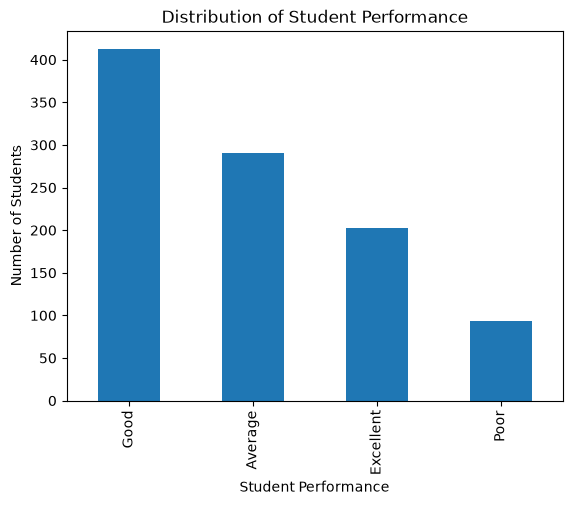

In [79]:
df["Student_Performance"].value_counts().plot(kind="bar")
plt.title("Distribution of Student Performance")
plt.xlabel("Student Performance")
plt.ylabel("Number of Students")
plt.show()


#### 4.1.1 Visual Interpretation

The bar chart shows that the Good performance category has the highest number of students, while Poor performance has the lowest. This is consistent with the earlier frequency analysis, where Good performance accounted for 41.3% of the dataset and Poor performance accounted for 9.3%.

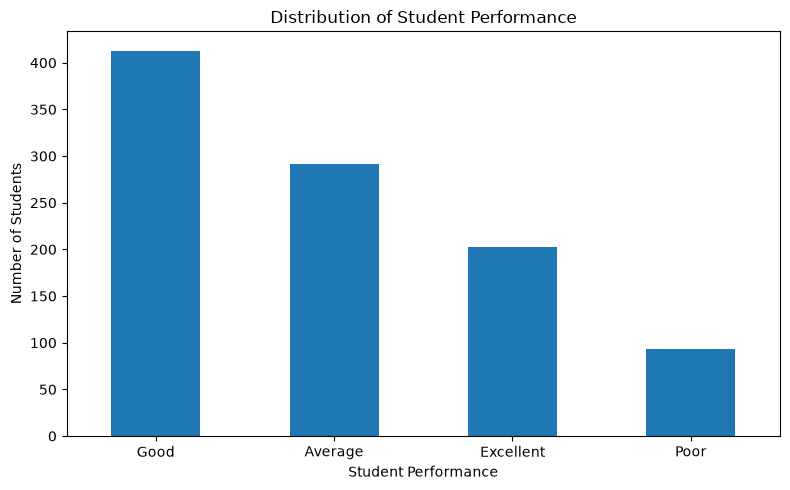

In [80]:
performance_counts = df["Student_Performance"].value_counts()

performance_counts.plot(kind="bar", figsize=(8,5))

plt.title("Distribution of Student Performance")
plt.xlabel("Student Performance")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Attendence and Final Grade

This analysis explores whether attendence percentage is associated with students' final grades. A scatter plot will be used to examine the relationship between these two numerical variables.

In [81]:
import pandas as pd
df = pd.read_csv("../data/Student_Performance.csv")



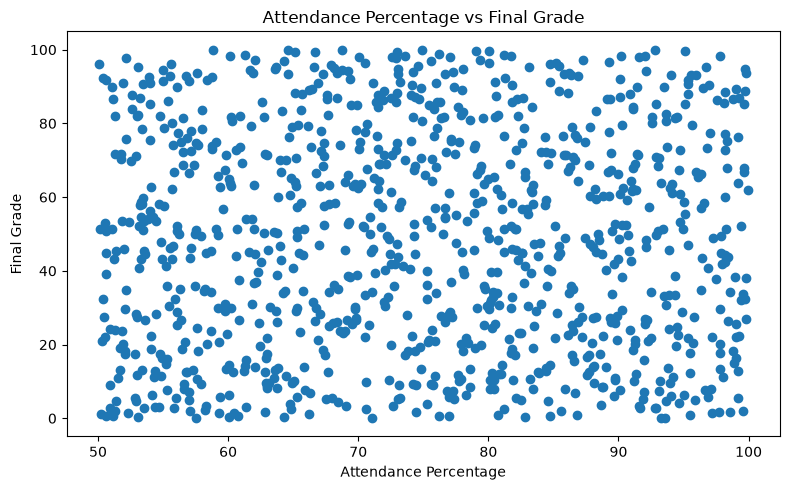

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["Attendance_Percentage"], df["Final_Grade"])

plt.title("Attendance Percentage vs Final Grade")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Grade")

plt.tight_layout()
plt.show()


#### 4.2.1 Visual Interpretation

The scatter plot shows no clear upward or downward pattern between attendance percentage and final grade. Students with similar attendance percentages appear to have a wide range of final grades. Based on visual inspection alone, there is no obvious linear relationship between the two variables.

In [83]:
attendance_correlation = df["Attendance_Percentage"].corr(df["Final_Grade"])
print("Attendance-final grade correlation:", round(attendance_correlation, 3))


Attendance-final grade correlation: 0.012


#### 4.2.2 Correlation Interpretation

The Pearson correlation between attendance percentage and final grade is 0.012. This indicates almost no linear relationship between the two variables in this dataset. The result is consistent with the scatter plot, which showed no clear upward or downward pattern.
This finding does not establish whether attendance causes changes in final grades.

### 4.3 Study Hours and Final Grade

This analysis explores the relationship between weekly study hours and final grades. A scatter plot will be used to examine whether students who study more hours tend to achieve higher grades.

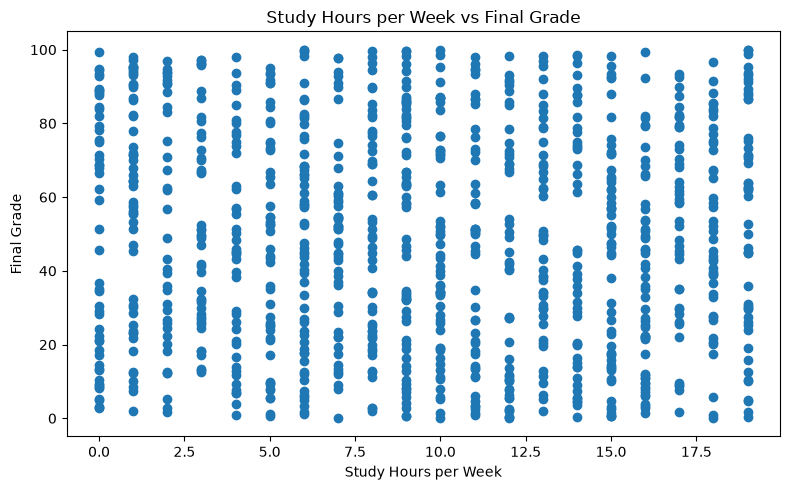

In [84]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours_per_Week"], df["Final_Grade"])

plt.title("Study Hours per Week vs Final Grade")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Grade")

plt.tight_layout()
plt.show()


In [85]:
df["Study_Hours_per_Week"].corr(df["Final_Grade"])

np.float64(-0.038838855149446225)

#### 4.3.1 Interpretation

The scatter plot shows vertical groups of points because study hours are recorded as whole numbers. There is no clear upward or downward trend in final grades as weekly study hours increase.

The Pearson correlation is approximately -0.039, indicating almost no linear relationship between weekly study hours and final grades in this dataset This result does not establish whether studying more or less causes changes in grades.

### 4.4. Assignments Completed and Final Garde

This Analysis explores whether the number of assignments completed is associated with students' final grades

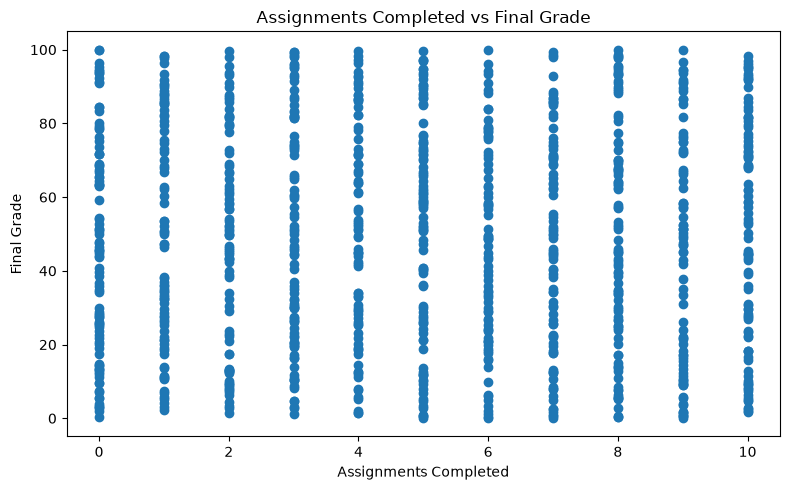

In [86]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Assignments_Completed"], df["Final_Grade"])

plt.title("Assignments Completed vs Final Grade")
plt.xlabel("Assignments Completed")
plt.ylabel("Final Grade")
plt.tight_layout()
plt.show()

In [87]:
df["Assignments_Completed"].corr(df["Final_Grade"])


np.float64(-0.001526061036838898)

#### 4.4.1 Interpretation

The Pearson correlation between assignments completed and final grade is approximately -0.002, indicating almost no linear relationship between the two variables in this dataset.

The scatter plot also shows that some students who completed assignments received low final grades Assignment completion alone therefore does not reliably distinguish students with higher final grades in this dataset.

### 4.5 Midterm Grade and Final Grade

This analysis examines the relationship between students' midterm grades and final grades using a scatter plot and Pearson correlation.

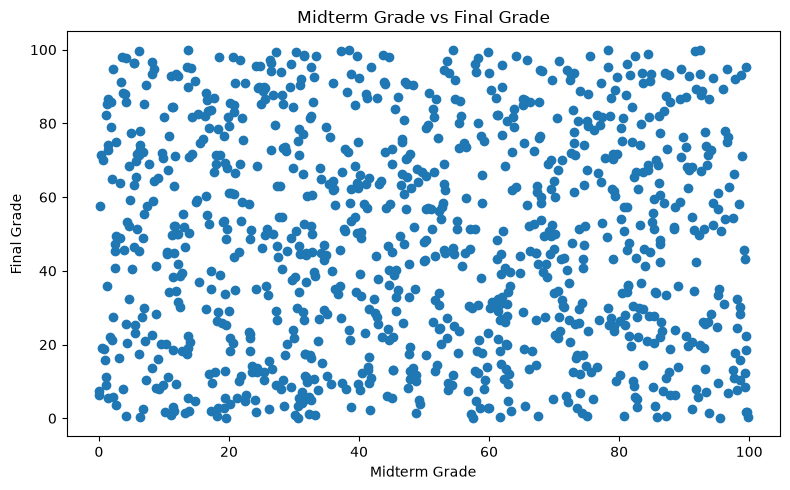

In [88]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Midterm_Grade"], df["Final_Grade"])

plt.title("Midterm Grade vs Final Grade")
plt.xlabel("Midterm Grade")
plt.ylabel("Final Grade")

plt.tight_layout()
plt.show()

In [89]:
df["Midterm_Grade"].corr(df["Final_Grade"])

np.float64(-0.012174108692403129)

#### 4.5.1 Interpretation

The scatter plot shows no clear upward or downward pattern between midterm grades and final grades.

The Pearson correlation is approximately -0.012, indicating almost no linear relationship between these variables in this dataset. This finding does not establish a causal relationship.

## 5. Summary of Findings

The analysis examined how attendance, weekly study hours, assignments completed, and midterm grades relate to final grades.

| Variable compared with final grade | Pearson correlation |
|---|---:|
| Attendance percentage | 0.012 |
| Study hours per week | -0.039 |
| Assignments completed | -0.002 |
| Midterm grade | -0.012 |

All four correlations are close to zero, indicating little to no linear association with final grade in this dataset. These results do not show that the factors are unimportant or that they have no causal effect on grades.

Good was the most common student performance category (41.3%), while Poor was the least common (9.3%).


## 6. Limitations

The dataset was obtained from the [Student Performance & Teaching Dataset on Kaggle](https://www.kaggle.com/datasets/zara2099/student-performance-and-teaching-dataset/data). 
Whether the records represent real students or were synthetically generated has not been confirmed. The findings should therefore not be generalised to real student populations or used on their own to make educational decisions.

This analysis focused on the linear relationships between final grades and four variables: attendance percentage, weekly study hours, assignments completed, and midterm grades. Pearson correlation does not capture every possible relationship, and a correlation close to zero does not mean that a variable has no effect on grades.

The analysis is exploratory. It does not establish cause and effect or account for other factors that may influence academic performance.